# Simple Random Palette Generation (sRGB and OKLCH)

Used for the article.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(429)

def show_palettes_rgb01(palettes_rgb01, title=None, n_cols=3):
    if len(palettes_rgb01) == 0:
        print("No palettes to display")
        return

    n_palettes = len(palettes_rgb01)
    n_rows = (n_palettes + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.4, n_rows * 0.9), squeeze=False)
    axes = axes.flatten()

    for i, palette in enumerate(palettes_rgb01):
        cmap = mcolors.ListedColormap(palette.tolist())
        axes[i].imshow([list(range(len(palette)))], cmap=cmap, aspect="auto")
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    for i in range(n_palettes, len(axes)):
        axes[i].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=12)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    else:
        plt.tight_layout()
    plt.show()

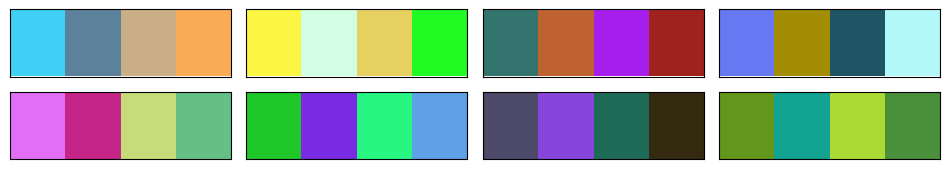

In [23]:
# Block 1: Naive random sRGB palettes
def random_rgb_palette(n_colors=4):
    rgb_bytes = np.random.randint(0, 256, size=(n_colors, 3), dtype=np.uint8)
    return rgb_bytes.astype(np.float32) / 255.0

rgb_palettes = [random_rgb_palette(4) for _ in range(8)]
show_palettes_rgb01(rgb_palettes, n_cols=4)

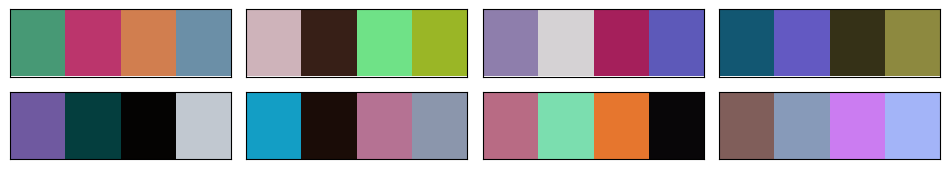

In [24]:
# Block 2: Random OKLCH palettes converted to sRGB
# We reject out-of-gamut colors (instead of clipping) to stay simple and faithful to the article idea.
def linear_to_srgb(u):
    return 12.92 * u if u <= 0.0031308 else 1.055 * (u ** (1.0 / 2.4)) - 0.055

def oklch_to_srgb01_if_in_gamut(oklch):
    L, C, h = float(oklch[0]), float(oklch[1]), float(oklch[2])
    h_rad = h * 2.0 * np.pi

    a = C * np.cos(h_rad)
    b = C * np.sin(h_rad)

    l_ = L + 0.3963377774 * a + 0.2158037573 * b
    m_ = L - 0.1055613458 * a - 0.0638541728 * b
    s_ = L - 0.0894841775 * a - 1.2914855480 * b

    l = l_ ** 3
    m = m_ ** 3
    s = s_ ** 3

    r_lin = 4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s
    g_lin = -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s
    b_lin = -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s

    rgb_lin = np.array([r_lin, g_lin, b_lin], dtype=np.float32)
    if np.any(rgb_lin < 0.0) or np.any(rgb_lin > 1.0):
        return None

    return np.array([linear_to_srgb(float(v)) for v in rgb_lin], dtype=np.float32)

def random_oklch_color_in_srgb(c_max=0.22, max_tries=200):
    for _ in range(max_tries):
        # Simple random OKLCH sampling
        color = np.array([np.random.rand(), np.random.rand() * c_max, np.random.rand()], dtype=np.float32)
        rgb = oklch_to_srgb01_if_in_gamut(color)
        if rgb is not None:
            return rgb
    return None

def random_oklch_palette(n_colors=4, c_max=0.22):
    colors = []
    for _ in range(n_colors):
        rgb = random_oklch_color_in_srgb(c_max=c_max)
        if rgb is None:
            return None
        colors.append(rgb)
    return np.stack(colors, axis=0)

oklch_palettes = []
while len(oklch_palettes) < 8:
    p = random_oklch_palette(n_colors=4, c_max=0.22)
    if p is not None:
        oklch_palettes.append(p)

show_palettes_rgb01(oklch_palettes, n_cols=4)